# 17_Random Forest

# Random Forest

Decision Tree는 Data로부터 Classification Rules를 Learning한다.

그러나 하나의 Decision Tree는 Training Data의 변화에 따라 다른 Tree가 만들어질 수 있으며, Tree가 복잡해지면 Overfitting이 발생할 수 있다.

이번에는 하나의 Tree가 아니라 여러 Decision Trees를 이용하여 Classification한다.

이 방법을 Random Forest라고 한다.

기본 아이디어는 다음과 같다.

> 여러 Decision Trees를 만들고 각각의 Prediction을 결합하여 최종 Class를 결정한다.

## From One Tree to Many Trees

Decision Tree 하나가 다음과 같이 Prediction했다고 하자.

$$
Tree_1 \rightarrow Class\ 1
$$

여러 Tree를 사용하면 각각 다른 Prediction을 할 수 있다.

$$
Tree_1 \rightarrow Class\ 1
$$

$$
Tree_2 \rightarrow Class\ 2
$$

$$
Tree_3 \rightarrow Class\ 1
$$

Classification에서는 여러 Tree의 Prediction을 종합하여 최종 Class를 결정한다.

위의 경우 Class 1을 선택할 수 있다.

## How Do We Make Different Trees?

Random Forest에서는 모든 Tree를 똑같이 만들지 않는다.

각 Tree를 만들 때

- Training Samples를 Random하게 선택하고
- 사용할 Features도 Random하게 선택한다.

따라서 각각의 Tree는 서로 다른 Data와 Features를 이용하여 만들어질 수 있다.

서로 다른 여러 Tree의 Prediction을 결합하여 하나의 Model보다 안정적인 Prediction을 얻는 것이 Random Forest의 기본 아이디어이다.

## Bootstrap Sampling

Random Forest는 각 Tree를 Training할 때 원래 Training Data에서 Samples를 Random하게 선택한다.

이때 같은 Sample이 여러 번 선택될 수도 있다.

이러한 방법을 Bootstrap Sampling이라고 한다.

각 Tree가 서로 다른 Training Samples를 사용하므로 서로 다른 Decision Tree가 만들어질 수 있다.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Test Data:", X_test.shape)

Training Data: (120, 4)
Test Data: (30, 4)


## Decision Tree

먼저 하나의 Decision Tree를 Training하여 Test Accuracy를 확인한다.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_pred = tree.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(
    "Decision Tree Accuracy:",
    tree_accuracy
)

Decision Tree Accuracy: 1.0


## Random Forest

이번에는 같은 Data에 Random Forest를 적용한다.

`n_estimators`는 Random Forest에서 사용할 Decision Trees의 수를 의미한다.

예를 들어

`n_estimators=100`

이면 100개의 Decision Trees를 사용한다.

In [3]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(
    X_train,
    y_train
)

forest_pred = forest.predict(
    X_test
)

forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)

print(
    "Random Forest Accuracy:",
    forest_accuracy
)

Random Forest Accuracy: 1.0


“100개의 Tree가 모두 똑같은 X_train으로 학습하는 것 아닌가?”라고 생각하기 쉽다.
하지만 RandomForestClassifier 내부에서 각 Tree마다 X_train으로부터 다시 Random Sampling을 합니다. 기본값이 bootstrap=True이기 때문이다. 예를 들어 Training Data가 120개라면 개념적으로 다음과 같다.

X_train: 120 Samples

Tree 1 → X_train에서 복원추출한 120 Samples
Tree 2 → X_train에서 복원추출한 120 Samples
Tree 3 → X_train에서 복원추출한 120 Samples
...
Tree 100 → X_train에서 복원추출한 120 Samples

복원추출이므로 같은 Sample이 한 Tree의 Training Data에 여러 번 들어갈 수도 있고, 어떤 Sample은 전혀 들어가지 않을 수도 있다. 이것이 Bootstrap Sampling.

각 Node에서 Split을 찾을 때도 모든 Feature를 사용하는 것이 아니라 Random하게 선택된 일부 Feature만 후보로 사용. RandomForestClassifier의 기본 max_features="sqrt"이므로 Iris처럼 Feature가 4개라면 각 Split에서 대략 2개의 Feature를 후보로 사용

## Decision Tree vs Random Forest

같은 Training Data와 Test Data에 두 Models을 적용하였다.

Decision Tree:

> 하나의 Tree를 이용하여 Prediction

Random Forest:

> 여러 Tree의 Prediction을 결합

두 Models의 Test Accuracy를 비교해 보자.

In [4]:
print(
    "Decision Tree:",
    f"{tree_accuracy:.3f}"
)

print(
    "Random Forest:",
    f"{forest_accuracy:.3f}"
)

Decision Tree: 1.000
Random Forest: 1.000


## Number of Trees

Random Forest에서 중요한 Parameter 중 하나는

`n_estimators`

이다.

이 값은 Forest를 구성하는 Decision Trees의 수를 의미한다.

Tree의 수를 변경하면서 Test Accuracy가 어떻게 변하는지 확인해 보자.

In [5]:
tree_numbers = [
    1,
    5,
    10,
    50,
    100,
    200
]

for n in tree_numbers:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        f"Trees={n}, "
        f"Accuracy={accuracy:.3f}"
    )

Trees=1, Accuracy=1.000
Trees=5, Accuracy=0.967
Trees=10, Accuracy=1.000
Trees=50, Accuracy=1.000
Trees=100, Accuracy=1.000
Trees=200, Accuracy=1.000


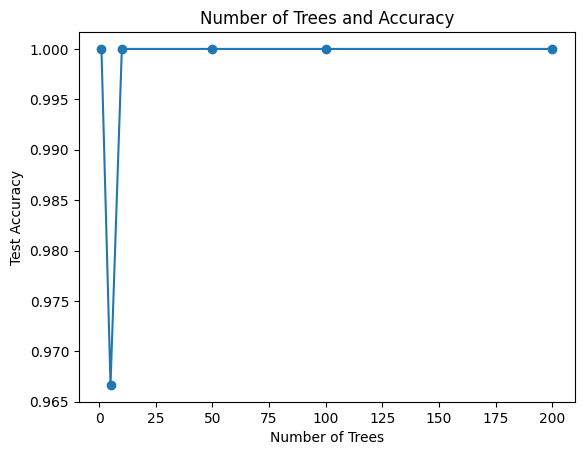

In [6]:
import matplotlib.pyplot as plt

accuracies = []

for n in tree_numbers:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    accuracies.append(
        model.score(
            X_test,
            y_test
        )
    )

plt.plot(
    tree_numbers,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Number of Trees and Accuracy")

plt.show()

## Feature Importance

Random Forest에서는 어떤 Feature가 Classification에 많이 사용되었는지도 확인할 수 있다.

이를 Feature Importance라고 한다.

In [7]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(
    X_train,
    y_train
)

for feature, importance in zip(
    iris.feature_names,
    forest.feature_importances_
):

    print(
        feature,
        f"{importance:.3f}"
    )

sepal length (cm) 0.108
sepal width (cm) 0.030
petal length (cm) 0.440
petal width (cm) 0.422


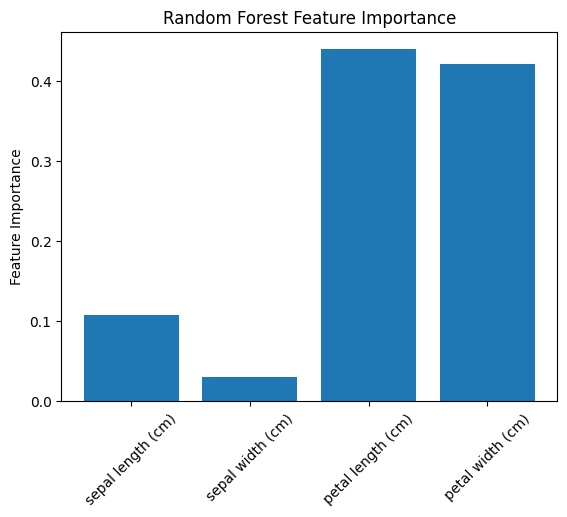

In [8]:
plt.bar(
    iris.feature_names,
    forest.feature_importances_
)

plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

## Summary

Decision Tree는 하나의 Tree를 이용하여 Classification한다.

Random Forest는 여러 Decision Trees를 만들어 그 결과를 결합한다.

기본 과정은 다음과 같다.

> Random Samples and Features → Multiple Decision Trees → Combine Predictions → Final Class

핵심 사항:

- 여러 Decision Trees를 사용한다.
- 각 Tree는 서로 다른 Samples와 Features를 이용할 수 있다.
- `n_estimators`는 사용할 Tree의 수이다.
- Tree의 수가 증가한다고 Accuracy가 계속 증가하는 것은 아니다.
- Feature Importance를 이용하여 Classification에 중요한 Features를 확인할 수 있다.

## Homework - Problem 17

Iris Dataset의 4개 Features를 모두 사용하여 Random Forest를 학습한다.

다음 조건을 사용한다.

- `test_size=0.2`
- `random_state=42`
- `n_estimators = 10, 50, 100`

다음 질문에 답하시오.

- 각 `n_estimators`의 Test Accuracy를 소수점 셋째 자리까지 적으시오.
- 가장 높은 Test Accuracy를 보인 `n_estimators`를 모두 적으시오.

답만 제출하시오.